# Regras de associação

A base de dados é composta por **145** características e **9'112** entradas.

Existe **5'011** duplicadas, que decidimos não remover, por considerar que pessoas diferentes poderiam de fato fazer as mesmas compras.


In [87]:
%%html
<link rel="stylesheet" href="./style.css">

import import_ipynb  # noqa: F401

In [88]:
import pandas as pd
from IPython.display import HTML, display
from mlxtend.frequent_patterns import apriori, association_rules

from columns import columns_names, get_name_of_column
from data import df
from plotting import plot_bar_graph


## Transações


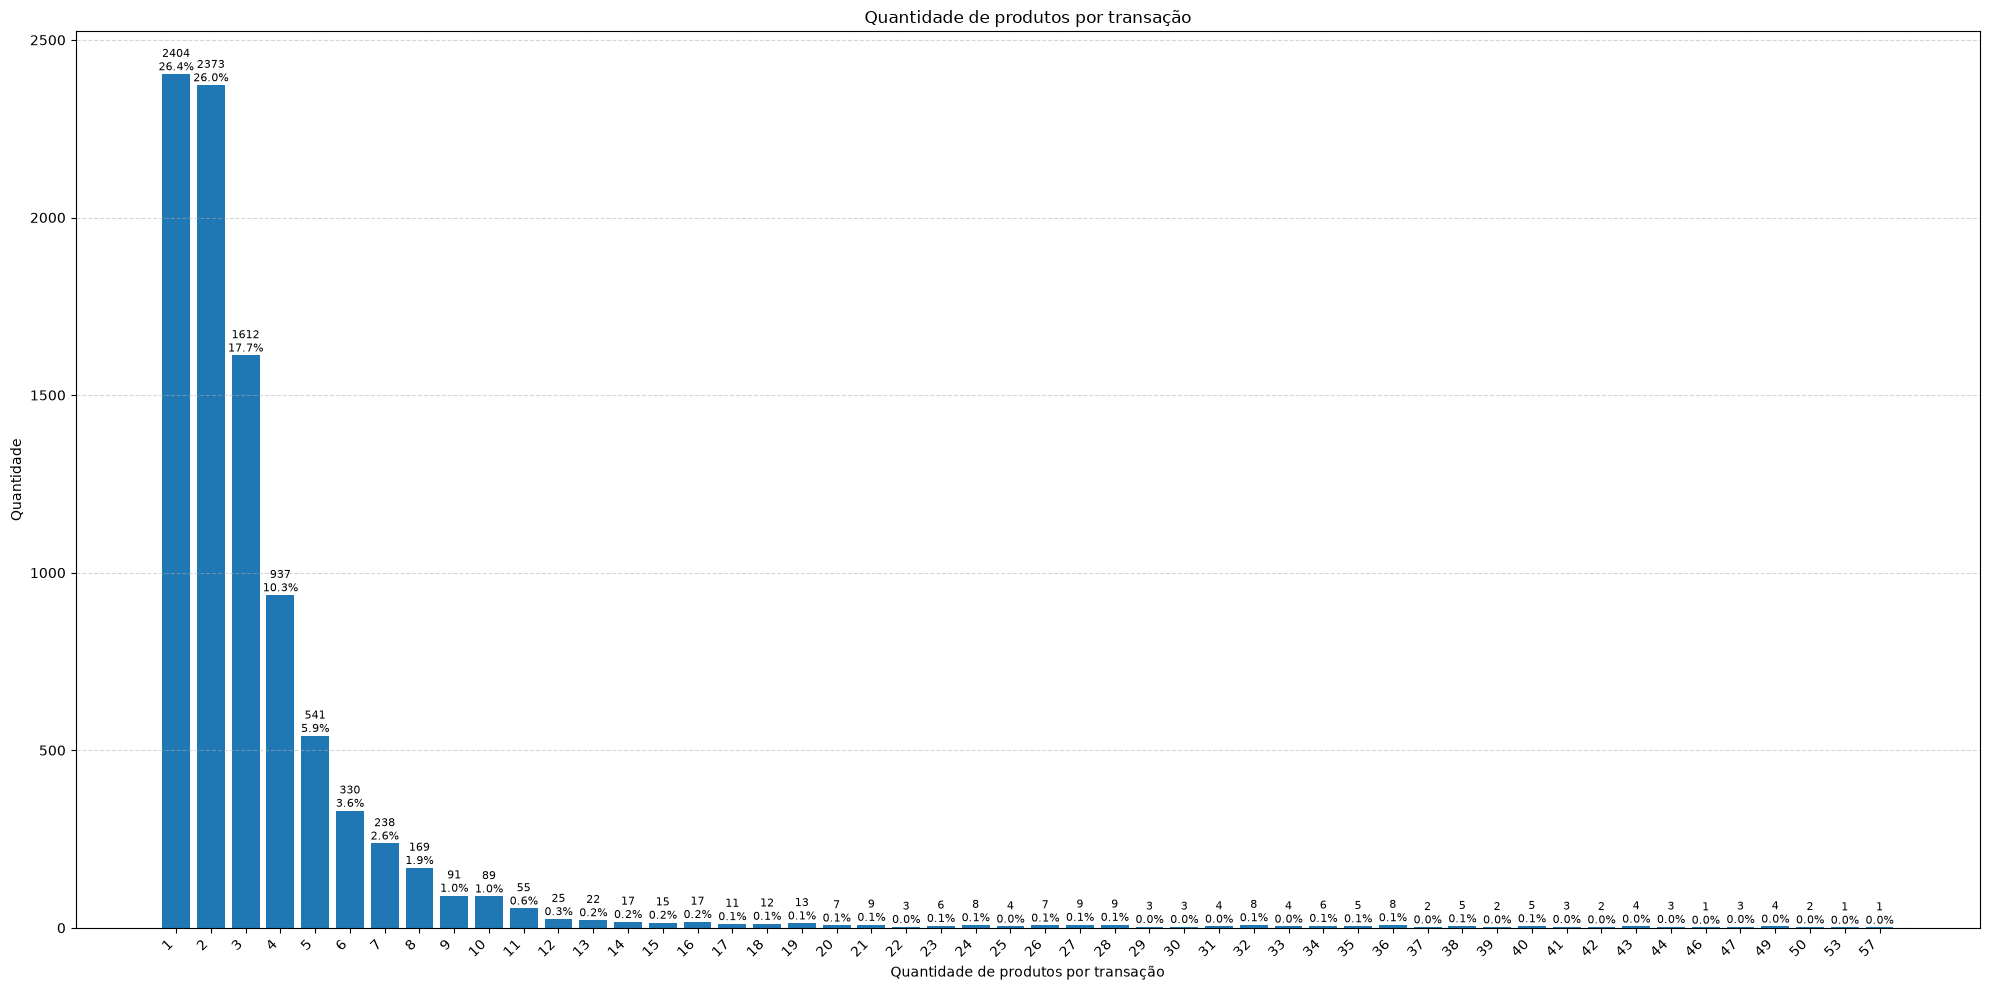

In [89]:
products_per_transaction = df.sum(axis=1).sort_values(ascending=False)
transaction_counts = products_per_transaction.value_counts()


def calculate_percentage(value, _):
    return value / len(df)


plot_bar_graph(
    transaction_counts,
    label="Quantidade de produtos por transação",
    title="Quantidade de produtos por transação",
    percentage_function=calculate_percentage,
    show_value=True,
    y_tick_step=500,
    sort_by="natural",
)

## Produtos frequentes


### Menos frequentes


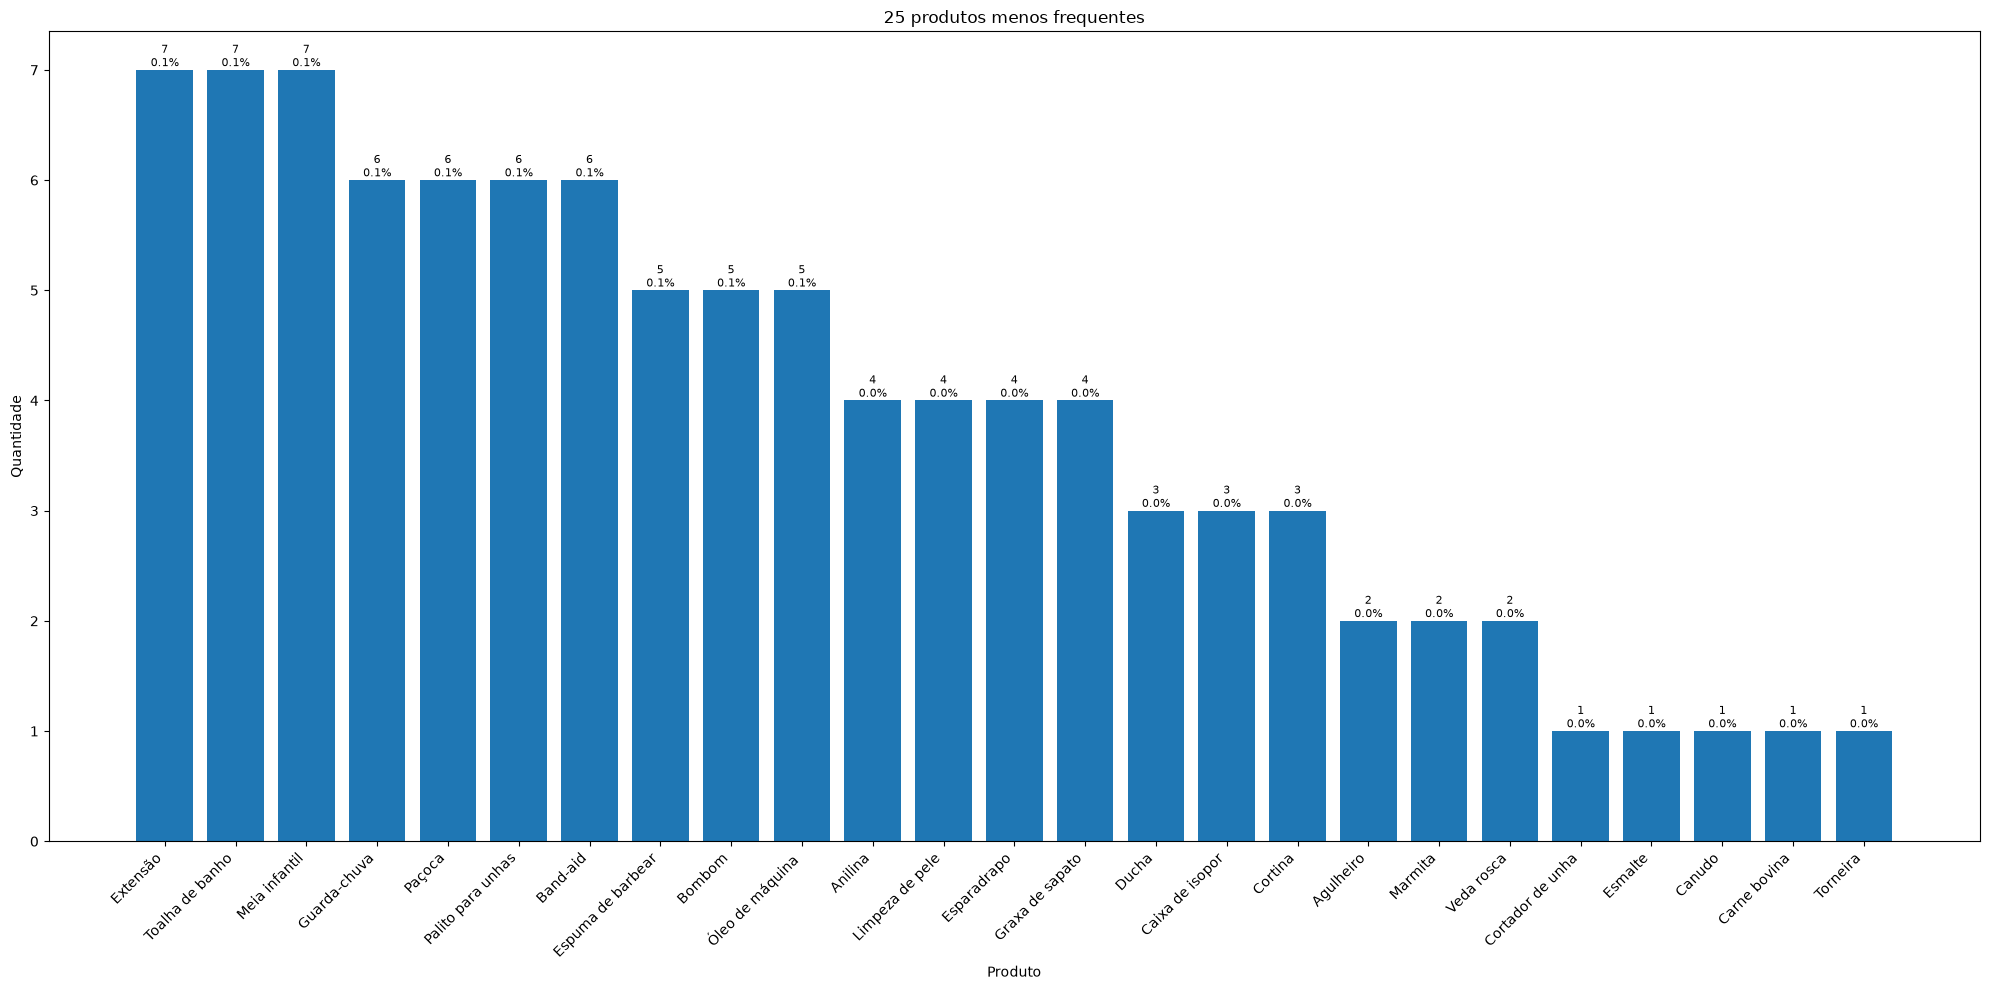

In [90]:
frequencies = df.sum().sort_values(ascending=False)

top_products = frequencies.tail(25).rename(index=dict(zip(df.columns, columns_names())))

plot_bar_graph(
    top_products,
    label="Produto",
    title="25 produtos menos frequentes",
    percentage_function=calculate_percentage,
    show_value=True,
    # y_tick_step=500,
    sort_by="frequency",
)

### Mais frequentes


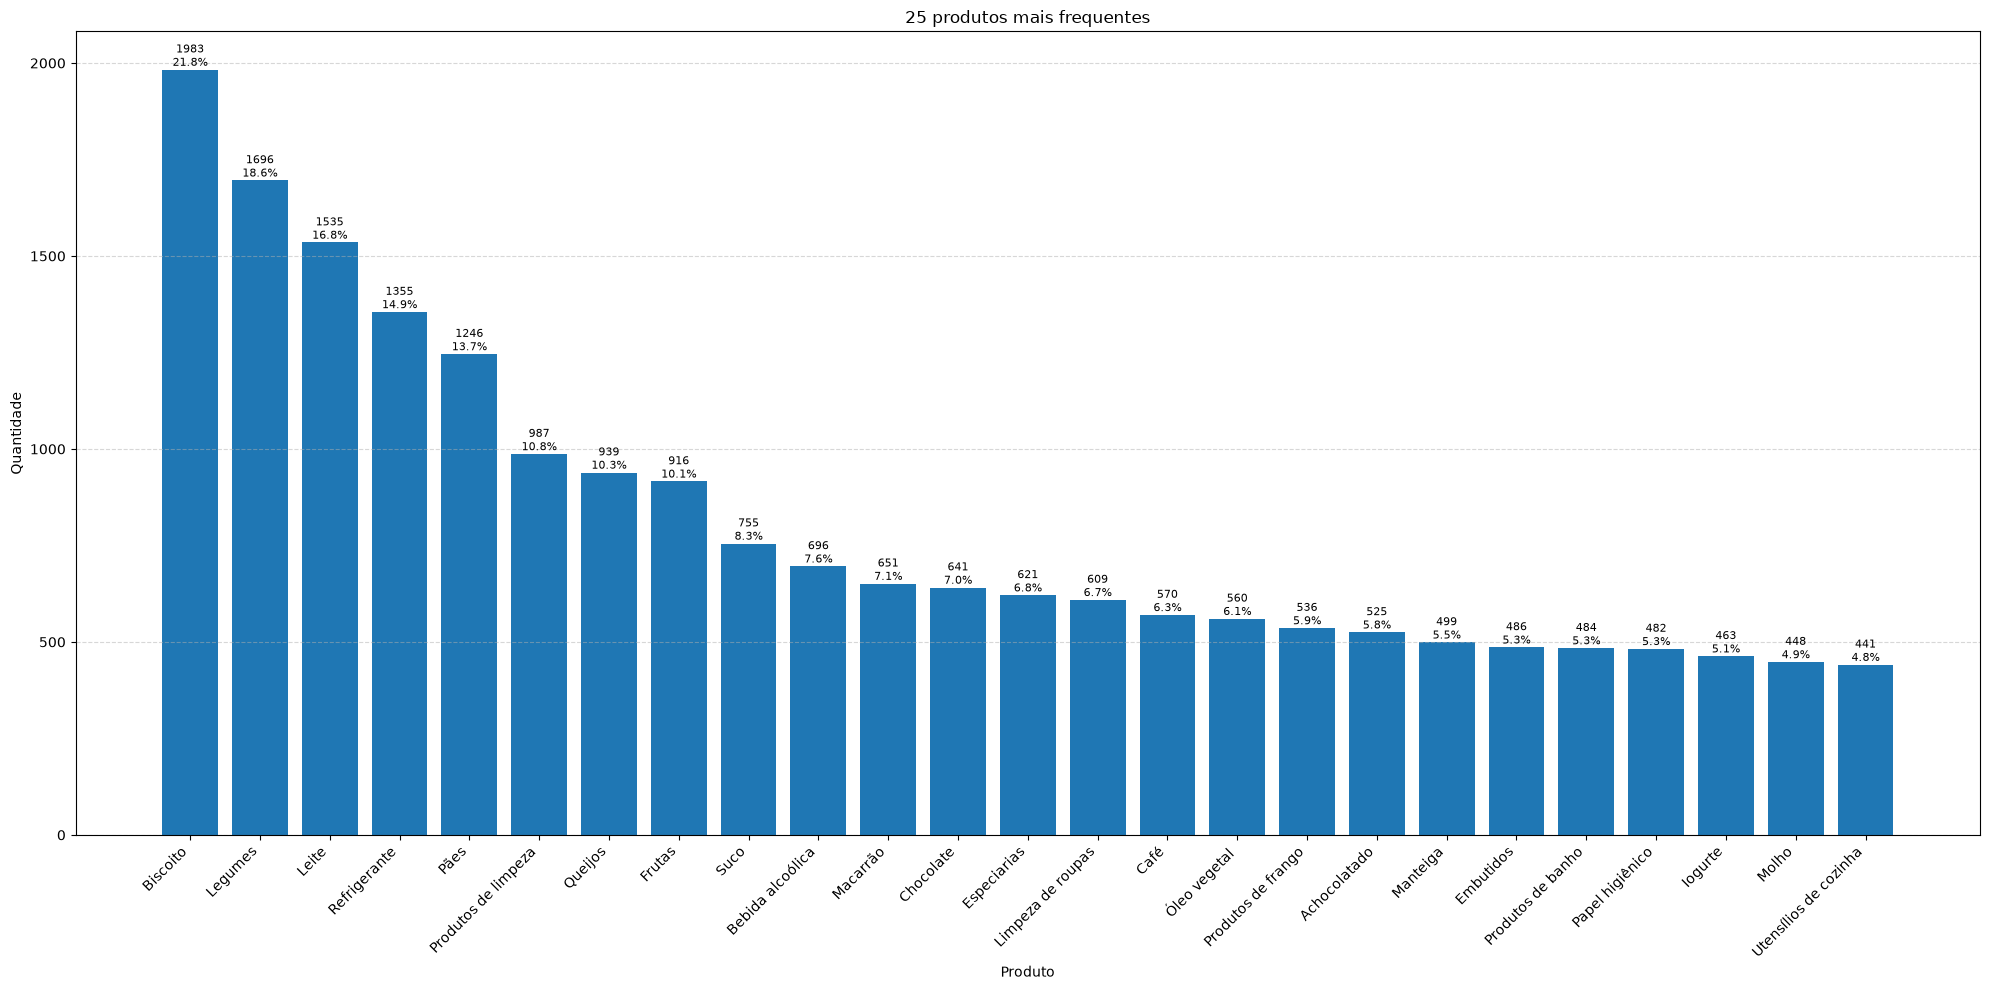

In [91]:
frequencies = df.sum().sort_values(ascending=False)

top_products = frequencies.head(25).rename(index=dict(zip(df.columns, columns_names())))

plot_bar_graph(
    top_products,
    label="Produto",
    title="25 produtos mais frequentes",
    percentage_function=calculate_percentage,
    show_value=True,
    y_tick_step=500,
    sort_by="frequency",
)

## Associações


### Apriori


In [92]:
def prepare_itemset_examples(
    itemsets,
    transaction_count,
    examples_per_size=5,
):
    data = itemsets.copy()

    data["itemset_size"] = data["itemsets"].apply(len)

    data["transaction_count"] = (
        (data["support"] * transaction_count).round().astype(int)
    )

    examples = []

    for size in sorted(data["itemset_size"].unique()):
        size_data = data[data["itemset_size"] == size]

        sample = size_data.nlargest(
            examples_per_size,
            "support",
        )

        examples.append(sample)

    result = pd.concat(examples)

    result["itemset"] = result["itemsets"].apply(
        lambda x: ", ".join(get_name_of_column(item) for item in sorted(x))
    )

    return result[
        [
            "itemset",
            "itemset_size",
            "support",
            "transaction_count",
        ]
    ]


def display_itemset_examples(
    itemsets,
    transaction_count,
    examples_per_size=5,
):
    examples = prepare_itemset_examples(
        itemsets,
        transaction_count,
        examples_per_size,
    )

    html = examples.to_html(
        index=False,
        formatters={
            "support": "{:.2%}".format,
        },
    )

    display(HTML(html))

#### Análise de valor de suporte


In [93]:
def generate_itemsets(data_frame: pd.DataFrame, min_support: float) -> pd.DataFrame:
    itemsets = apriori(data_frame, min_support=min_support, use_colnames=True)

    itemsets["itemset_size"] = itemsets["itemsets"].apply(len)
    itemsets["transaction_count"] = (
        (itemsets["support"] * len(data_frame)).round().astype(int)
    )

    return itemsets

In [94]:
def display_itemsets(
    itemsets: pd.DataFrame,
    min_support: float,
):
    table_code = f"""
    <table>
        <caption>
            Frequent itemsets — minimum support = {min_support:.3f}
        </caption>
        <thead>
            <tr>
                <th>Itemset</th>
                <th>Size</th>
                <th>Support</th>
                <th>Transactions</th>
            </tr>
        </thead>
        <tbody>
    """

    for _, row in itemsets.iterrows():
        items = ", ".join(sorted(row["itemsets"]))

        table_code += f"""
            <tr>
                <td>{{items}}</td>
                <td>{row["itemset_size"]}</td>
                <td>{row["support"]:.4f}</td>
                <td>{row["transaction_count"]}</td>
            </tr>
        """

    table_code += """
        </tbody>
    </table>
    """

    display(HTML(table_code))

In [95]:
def analyze_support(
    data_frame: pd.DataFrame,
    min_support: float,
) -> pd.DataFrame:
    itemsets = generate_itemsets(data_frame, min_support)

    display_itemsets(itemsets, min_support)

    return itemsets

In [96]:
def summarize_support(
    data_frame: pd.DataFrame,
    support_values: list[float],
) -> pd.DataFrame:
    results = []

    for support in support_values:
        itemsets = generate_itemsets(data_frame, support)

        results.append(
            {
                "Support": support,
                "itemsets": len(itemsets),
                "1-itemsets": (itemsets["itemset_size"] == 1).sum(),
                "2-itemsets": (itemsets["itemset_size"] == 2).sum(),
                "3-itemsets": (itemsets["itemset_size"] == 3).sum(),
                "4+-itemsets": (itemsets["itemset_size"] >= 4).sum(),
            }
        )

    return pd.DataFrame(results)

In [97]:
support_values = [0.01, 0.02, 0.03, 0.05, 0.10]

support_summary = summarize_support(df, support_values)

display(HTML(support_summary.to_html(index=False, float_format="{:.2f}".format)))

Support,itemsets,1-itemsets,2-itemsets,3-itemsets,4+-itemsets
0.01,1299,72,352,455,420
0.02,121,48,72,1,0
0.03,64,41,22,1,0
0.05,23,23,0,0,0
0.10,8,8,0,0,0


- Considerando um valor mínimo de suporte de `1%`, um conjunto muito grande de itemsets é encontrado, o que não distingue muita informação.
- Para o valor de `2%`, percebe-se uma redução acentuada da quantidade de itemsets, o que permite separar bastante as regras realmente úteis.
- O valor de `3%` acompanha a interpretação de `2%`, porém mais restrito.
- Os valores de `5%` e `10%` restringem demais a identificação de itemsets, e perdem informação interessante.


In [98]:
support_values = [0.010, 0.0125, 0.015, 0.0175, 0.020]

support_summary = summarize_support(df, support_values)

display(HTML(support_summary.to_html(index=False, float_format="{:.4f}".format)))

Support,itemsets,1-itemsets,2-itemsets,3-itemsets,4+-itemsets
0.0100,1299,72,352,455,420
0.0125,462,64,225,158,15
0.0150,232,56,150,26,0
0.0175,166,53,111,2,0
0.0200,121,48,72,1,0


- O valor de `1.25%` delimita expressivamente a quantidade de itemsets, mas ainda preserva `15` conjuntos grandes.
- Valores maiores restringem bastante, e perdem informação.


In [99]:
min_support = 0.0125

itemsets = apriori(
    df,
    min_support=0.0125,
    use_colnames=True,
)

display(
    HTML(
        "<h4>Itemsets identificados</h4><ul><li>Itemsets: 462</li><li>Itens únicos: 64</li><li>Duplas: 225</li><li>3-úplas: 158</li><li>4+-úplas: 15</li></ul><p>Apenas algumas linhas foram selecionadas, para demonstração.</p>"
    )
)

display_itemset_examples(
    itemsets,
    len(df),
    examples_per_size=5,
)

itemset,itemset_size,support,transaction_count
Biscoito,1,21.76%,1983
Legumes,1,18.61%,1696
Leite,1,16.85%,1535
Refrigerante,1,14.87%,1355
Pães,1,13.67%,1246
"Frutas, Legumes",2,4.71%,429
"Biscoito, Leite",2,4.61%,420
"Legumes, Leite",2,4.48%,408
"Biscoito, Legumes",2,4.12%,375
"Biscoito, Refrigerante",2,3.90%,355


#### Análise de regras de associação

Fixado threshold de suporte em `0.8`.


In [100]:
def display_rule_analysis(rules):
    data = rules.copy()

    data["antecedents"] = data["antecedents"].apply(
        lambda x: ", ".join(get_name_of_column(item) for item in sorted(x))
    )

    data["consequents"] = data["consequents"].apply(
        lambda x: ", ".join(get_name_of_column(item) for item in sorted(x))
    )

    data["support"] = data["support"].apply(lambda x: f"{x * 100:.2f}%")

    data["leverage"] = data["leverage"].apply(lambda x: f"{x * 100:.2f} pp")

    data = data[
        [
            "antecedents",
            "consequents",
            "support",
            "confidence",
            "lift",
            "leverage",
            "conviction",
        ]
    ]

    data = data.rename(
        columns={
            "antecedents": "Antecedents",
            "consequents": "Consequents",
            "support": "Support",
            "confidence": "Confidence",
            "lift": "Lift",
            "leverage": "Leverage",
            "conviction": "Conviction",
        }
    )

    display(
        HTML(
            data.to_html(
                index=False,
            )
        )
    )

- **Antecedents**: itens comprados em conjunto.

- **Consequents**: itens frequentemente comprados quando se coloca os antecedentes no carrinho.

- **Support**: Porcentagem de transações que contém ambos os antecedentes juntos.

- **Confidence**: Probabilidade de o consequente ser colocado no carrinho quando os antecedentes já foram colocados.

- **Lift**: Força da regra associação em comparação a uma seleção aleatória dos produtos.

- **Leverage**: Diferença em pontos percentuais do suporte ocorrido em co-ocorrência em comparação ao suporte individual dos itens.

- **Conviction**: O quão fortemente os antecedentes implicam o consequente, baseado nas falhas de constatação da regra.


In [101]:
rules = association_rules(
    itemsets,
    metric="confidence",
    min_threshold=0.8,
).sort_values(
    by="lift",
    ascending=False,
)

display_rule_analysis(rules)

Antecedents,Consequents,Support,Confidence,Lift,Leverage,Conviction
"Creme, Leite",Creme de leite,3.12%,0.910256,29.205128,3.01 pp,10.795560
Creme de leite,"Creme, Leite",3.12%,1.000000,29.205128,3.01 pp,inf
"Creme de leite, Legumes","Creme, Leite",1.46%,1.000000,29.205128,1.41 pp,inf
"Creme, Legumes, Leite",Creme de leite,1.46%,0.886667,28.448263,1.41 pp,8.548520
Comida congelada,Gel,3.07%,1.000000,23.791123,2.94 pp,inf
"Açúcar, Café, Feijão",Arroz,1.25%,0.912000,22.399310,1.20 pp,10.900960
"Café, Feijão, Produtos de limpeza",Arroz,1.28%,0.906977,22.275936,1.23 pp,10.312308
"Creme de leite, Leite",Creme,3.12%,1.000000,22.116505,2.98 pp,inf
"Creme de leite, Legumes",Creme,1.46%,1.000000,22.116505,1.39 pp,inf
"Creme de leite, Legumes, Leite",Creme,1.46%,1.000000,22.116505,1.39 pp,inf


- Laticínios
  - Sempre que se compra `Creme de Leite`, compra-se `Leite` e `Creme`.
  - Outras regras associam esses produtos e também `Leite condensado` de diferentes formas.

- Alimentação básica
  - Comumente ao comprar `Feijão`, `Café`, `Açúcar` e relacionados, compra-se `Arroz`.
  - Outras direções de associação entre eles são comuns.
  - `Óleo de cozinha` se encontra nesse grupo também.

- Limpeza
  - `Produtos de limpeza`, `Limpeza de roupas` e `Papel higiênicos` aparecem juntos com frequência.
  - Eles se relacionam bastante com produtos da alimentação básica.

- Sanduíche
  - Ao comprar `Pães` e `Presunto`, é comum comprar `Queijos`.
